In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [ ]:
# Importação das bibliotecas necessárias

from sklearn.model_selection import train_test_split
from modulos.gerais import exibir_resultado, exibir_relatorio_de_classificacao, preparar_heart_disease
from modulos.arvore_de_decisao import executar_arvore_de_decisao, exibir_regras_da_arvore_de_decisao, gerar_grafico_da_arvore_de_decisao


In [3]:
# Importação e exploração dos dados
X, y, feature_names, target_names = preparar_heart_disease()

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)


In [4]:
(clf, y_pred_arvore_de_decisao, acuracia_arvore_decisao, precisao_arvore_decisao,
revocacao_arvore_decisao, f1_arvore_decisao) = executar_arvore_de_decisao(X_train, y_train, X_test, y_test)


In [5]:
# Exibição dos resultados das métricas usando Árvore de Decisão com Digits
exibir_resultado(
    acuracia_arvore_decisao, precisao_arvore_decisao,
    revocacao_arvore_decisao, f1_arvore_decisao,
    "ÁRVORE DE DECISÃO"
    )


MÉTRICAS DE AVALIAÇÃO - ÁRVORE DE DECISÃO
Acurácia:  0.7444
Precisão:  0.7494
Revocação: 0.7381
F1-Score:  0.7390




In [6]:
# Exibição das Regras Geradas
exibir_regras_da_arvore_de_decisao(clf, feature_names)



REGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):
|--- thal <= 4.50
|   |--- oldpeak <= 2.10
|   |   |--- ca <= 2.50
|   |   |   |--- class: 0
|   |   |--- ca >  2.50
|   |   |   |--- class: 1
|   |--- oldpeak >  2.10
|   |   |--- trestbps <= 112.00
|   |   |   |--- class: 0
|   |   |--- trestbps >  112.00
|   |   |   |--- class: 1
|--- thal >  4.50
|   |--- oldpeak <= 0.55
|   |   |--- chol <= 233.50
|   |   |   |--- class: 0
|   |   |--- chol >  233.50
|   |   |   |--- class: 1
|   |--- oldpeak >  0.55
|   |   |--- cp <= 3.50
|   |   |   |--- class: 1
|   |   |--- cp >  3.50
|   |   |   |--- class: 1



In [7]:
# Exibição do relatório de classificação da Árvore de Decisão com Heart Disease
exibir_relatorio_de_classificacao(y_test, y_pred_arvore_de_decisao, target_names)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

    saudavel       0.73      0.83      0.78        48
  com_doenca       0.77      0.64      0.70        42

    accuracy                           0.74        90
   macro avg       0.75      0.74      0.74        90
weighted avg       0.75      0.74      0.74        90



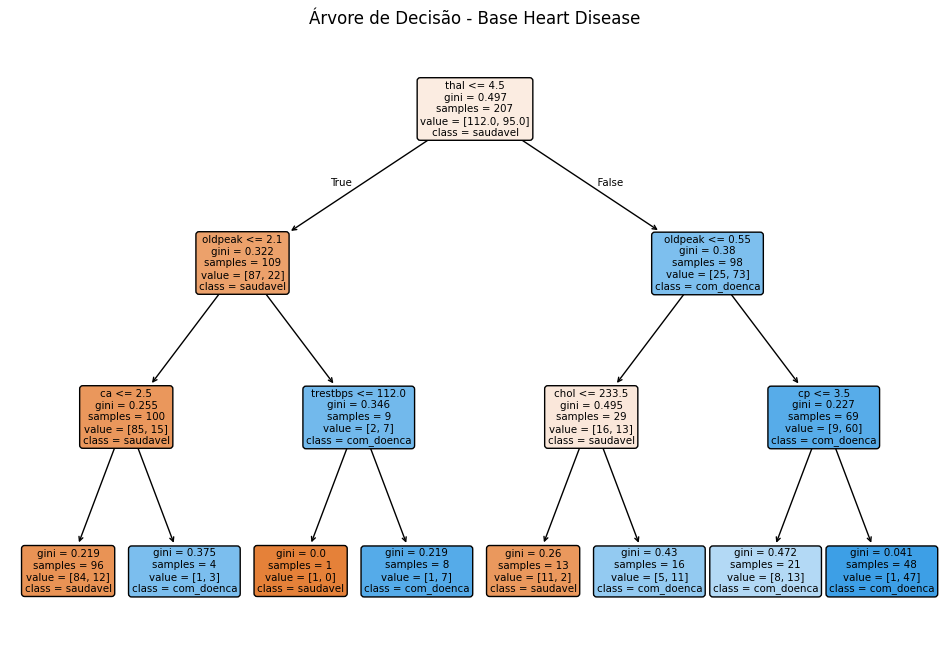

In [8]:
# Representação Gráfica da Árvore
gerar_grafico_da_arvore_de_decisao(clf, feature_names, target_names, 'Heart Disease')
